In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import(accuracy_score, f1_score, r2_score, confusion_matrix, classification_report, precision_score,recall_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import (DecisionTreeClassifier, plot_tree)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV

In [2]:
df=pd.read_csv("diabetes_dirty_dataset.csv")
df

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,NaN,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,NaN,3.0,0
1011,P0746,2,131,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0


In [3]:
df=df.drop(columns=["PatientID"])

In [4]:
df["Glucose"]=df["Glucose"].str.strip("!@#$%^&*({}[];',//loO?)")
df["Glucose"]=df["Glucose"].astype(float)
df["Outcome"]=df["Outcome"].replace({"0":0.0,"1":1.0,"Yes":1.0,"No":0.0,"True":1.0,"False":0.0,"TRUE":1.0,"FALSE":0.0})
df["Outcome"]=df["Outcome"].astype(float)



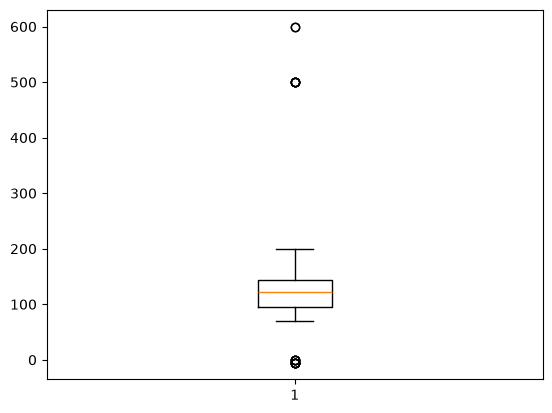

In [5]:
plt.boxplot(df["Glucose"].dropna())
q1=df["Glucose"].quantile(0.25)
q3=df["Glucose"].quantile(0.75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
df=df[(df["Glucose"]<=ub) & (df["Glucose"]>=lb)]
df["Glucose"]=df["Glucose"].fillna(df["Glucose"].median())
df["VitaminD"]=df["VitaminD"].fillna(df["VitaminD"].median())

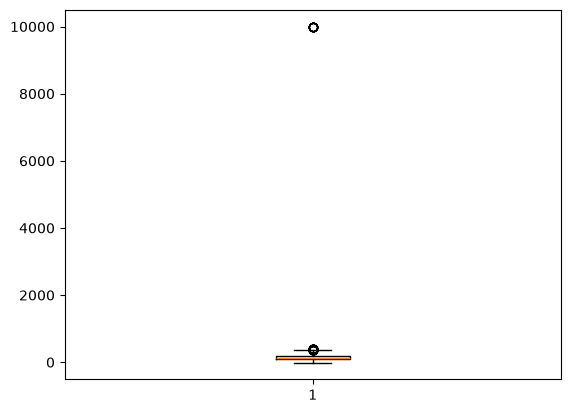

In [6]:
df["ExerciseHrsPerWeek"]=df["ExerciseHrsPerWeek"].fillna(df["ExerciseHrsPerWeek"].median())
plt.boxplot(df["Insulin"].dropna())
q1=df["Insulin"].quantile(0.25)
q3=df["Insulin"].quantile(0.75)
iqr=q3-q1
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
df=df[(df["Insulin"]<ub) & (df["Insulin"]>lb)]

In [ ]:
df
X=df.drop(columns=["Outcome"])
X
y=df["Outcome"]
X.isnull().sum()


Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness               63
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                     0
ExerciseHrsPerWeek           0
dtype: int64

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,stratify=y)

In [13]:
df["SkinThickness"]=df["SkinThickness"].fillna(df["SkinThickness"].median())

In [14]:
X.isnull().sum()

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness               63
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                     0
ExerciseHrsPerWeek           0
dtype: int64

In [21]:
preprocessor=Pipeline([
    ("scaler",StandardScaler()),
    ("model",RandomForestClassifier())
])
param_grid={
    "model__n_estimators":[100,200],
    "model__max_depth": range(1,7)
}
grid=GridSearchCV(
    preprocessor,
    param_grid,
    cv=5,
    scoring="f1"
)

In [22]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': range(1, 7), 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of in

In [23]:
print(grid.best_params_)

{'model__max_depth': 4, 'model__n_estimators': 100}


In [26]:
best_model = grid.best_estimator_

print(best_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(max_depth=4))])


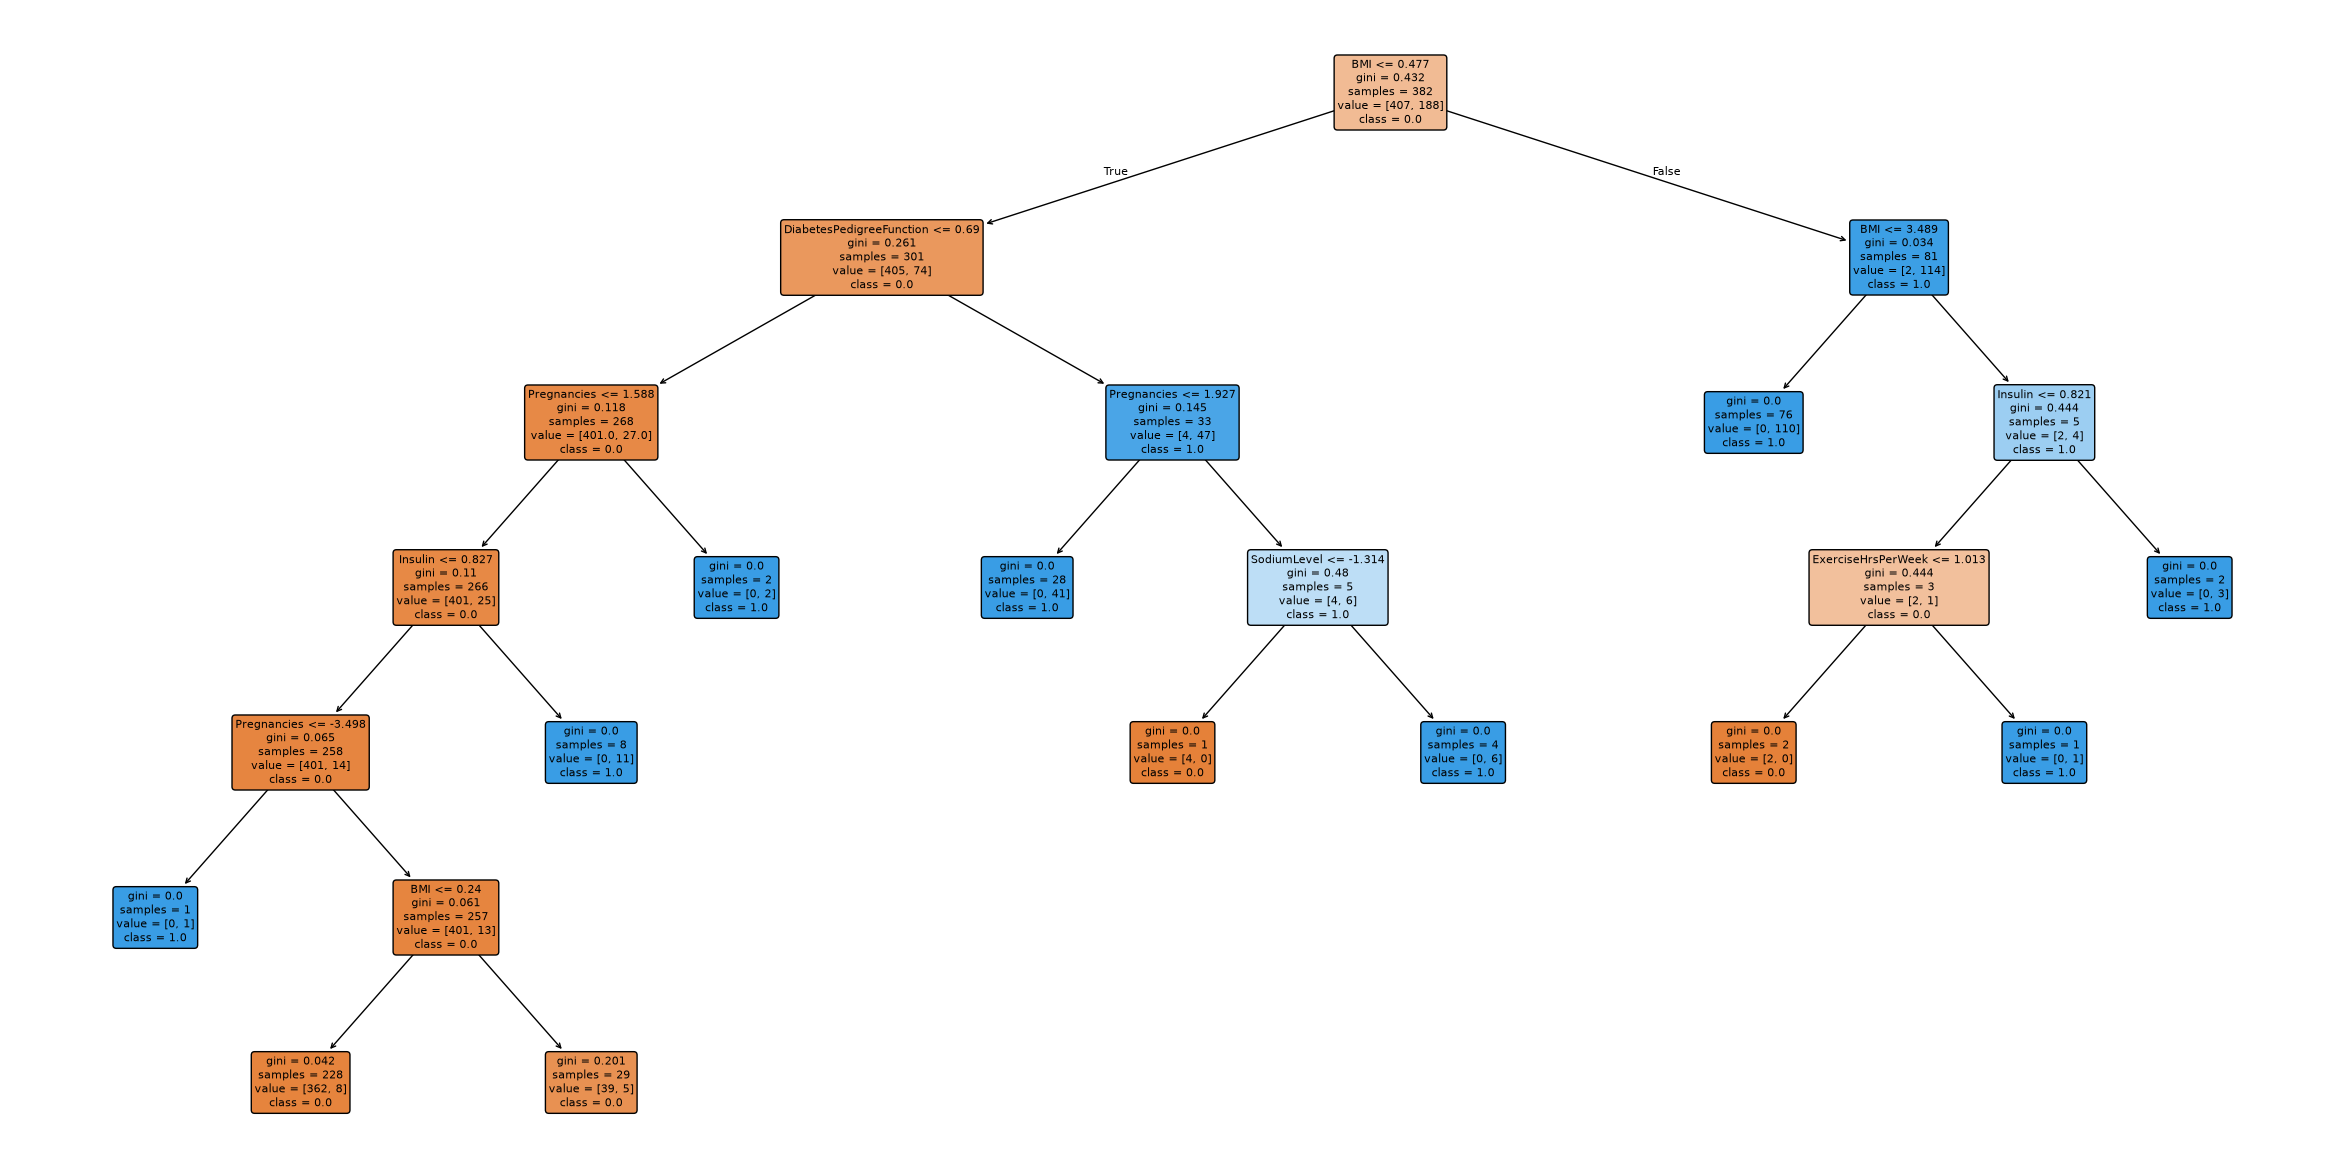

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Fit GridSearchCV
grid.fit(X_train, y_train)

# Get the best Random Forest
best_rf = grid.best_estimator_.named_steps["model"]

# Get feature names
feature_names = X_train.columns

# Select one tree from the best forest
best_tree = best_rf.estimators_[0]

# Plot the FULL tree
plt.figure(figsize=(30, 15))

plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=[str(c) for c in best_rf.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()